### Установка зависимостей 

In [1]:
# %pip install transformers torch matplotlib seaborn bertviz numpy pandas
# %pip install -q ipywidgets


In [2]:
# Импорт необходимых библиотек
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    AutoTokenizer, AutoModel,
    BertTokenizer, BertModel,
    GPT2Tokenizer, GPT2Model,
    T5Tokenizer, T5Model
)
from bertviz import model_view, head_view
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline


## Часть 1: Основные задания (обязательная часть)

### Задание 1.1: Загрузка и подготовка моделей

In [3]:
# Загружаем модели для сравнения
models_info = {
    'BERT': {
        'model_name': 'bert-base-uncased',
        'tokenizer': None,
        'model': None
    },
    'GPT-2': {
        'model_name': 'gpt2',
        'tokenizer': None,
        'model': None
    }
}

# Загружаем токенизаторы и модели
models_info['BERT']['tokenizer'] = AutoTokenizer.from_pretrained(
    models_info['BERT']['model_name']
)
models_info['BERT']['model'] = AutoModel.from_pretrained(
    models_info['BERT']['model_name'],
    output_attentions=True
)

models_info['GPT-2']['tokenizer'] = AutoTokenizer.from_pretrained(
    models_info['GPT-2']['model_name']
)
models_info['GPT-2']['model'] = AutoModel.from_pretrained(
    models_info['GPT-2']['model_name'],
    output_attentions=True
)

print("Модели загружены успешно!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     | Details
-------------------------------------------+------------+--------
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |        
cls.predictions.bias                       | UNEXPECTED |        
cls.predictions.transform.dense.weight     | UNEXPECTED |        
cls.seq_relationship.weight                | UNEXPECTED |        
cls.predictions.transform.dense.bias       | UNEXPECTED |        
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |        
cls.seq_relationship.bias                  | UNEXPECTED |        

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Модели загружены успешно!


### Задание 1.2: Токенизация и получение attention весов

In [4]:
test_text = "The cat sat on the mat and looked at the dog."
print(f"Анализируемый текст: {test_text}")

def get_attention_weights(text, model_name):
    """
    Получение attention весов для заданного текста и модели
    """
    tokenizer = models_info[model_name]['tokenizer']
    model = models_info[model_name]['model']

    # Токенизация
    inputs = tokenizer(text, return_tensors="pt")

    # Прямой проход без вычисления градиентов
    with torch.no_grad():
        outputs = model(**inputs)

    # Attention веса: tuple из тензоров по слоям
    attention_weights = outputs.attentions

    # Перевод id токенов в текстовые токены
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    return attention_weights, tokens, inputs

# Получаем attention веса для обеих моделей
bert_attention, bert_tokens, bert_inputs = get_attention_weights(test_text, 'BERT')
gpt2_attention, gpt2_tokens, gpt2_inputs = get_attention_weights(test_text, 'GPT-2')

print(f"BERT tokens: {bert_tokens}")
print(f"GPT-2 tokens: {gpt2_tokens}")
print(f"BERT attention shape: {bert_attention[0].shape}")
print(f"GPT-2 attention shape: {gpt2_attention[0].shape}")

Анализируемый текст: The cat sat on the mat and looked at the dog.
BERT tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'and', 'looked', 'at', 'the', 'dog', '.', '[SEP]']
GPT-2 tokens: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', 'Ġand', 'Ġlooked', 'Ġat', 'Ġthe', 'Ġdog', '.']
BERT attention shape: torch.Size([1, 12, 14, 14])
GPT-2 attention shape: torch.Size([1, 12, 12, 12])


[CLS] - это специальный токен в начале текста, 
[SEP] - специальный токен-разделитель,
Ġ = пробел перед словом

### Задание 1.3: Создание базовой attention heatmap

In [5]:
def plot_attention_heatmap(attention_weights, tokens, model_name, layer_idx=0, head_idx=0):
    attention_matrix = attention_weights[layer_idx][0, head_idx].cpu().numpy()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attention_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='Blues',
        cbar=True,
        square=True
    )

    plt.title(f'{model_name} - Layer {layer_idx}, Head {head_idx}\nAttention Weights')
    plt.xlabel('Key (Attended to)')
    plt.ylabel('Query (Attending from)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

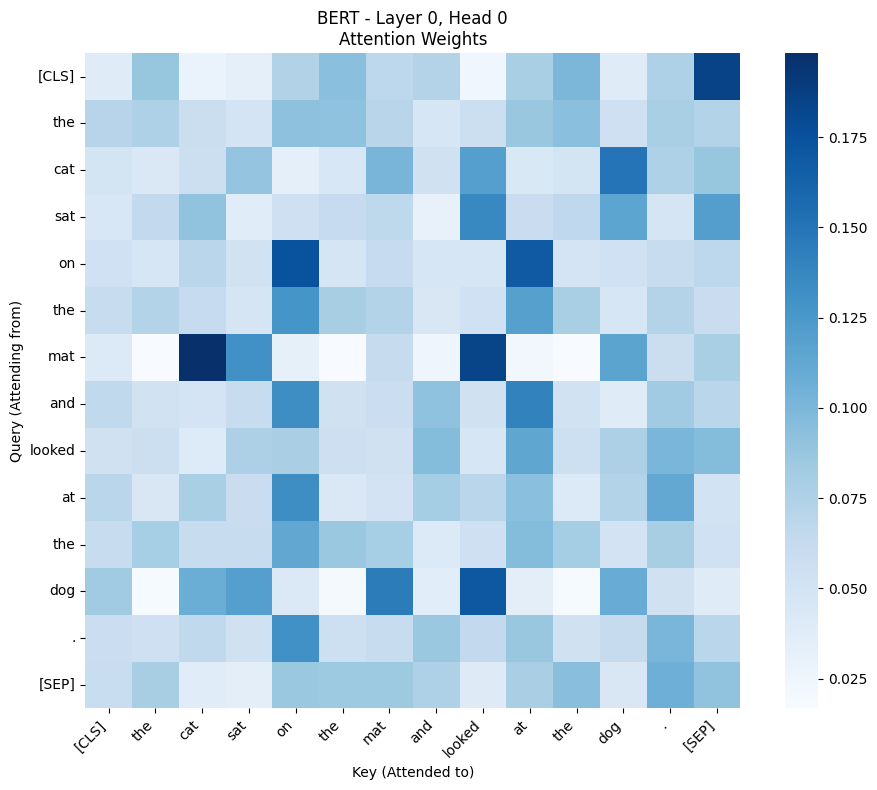

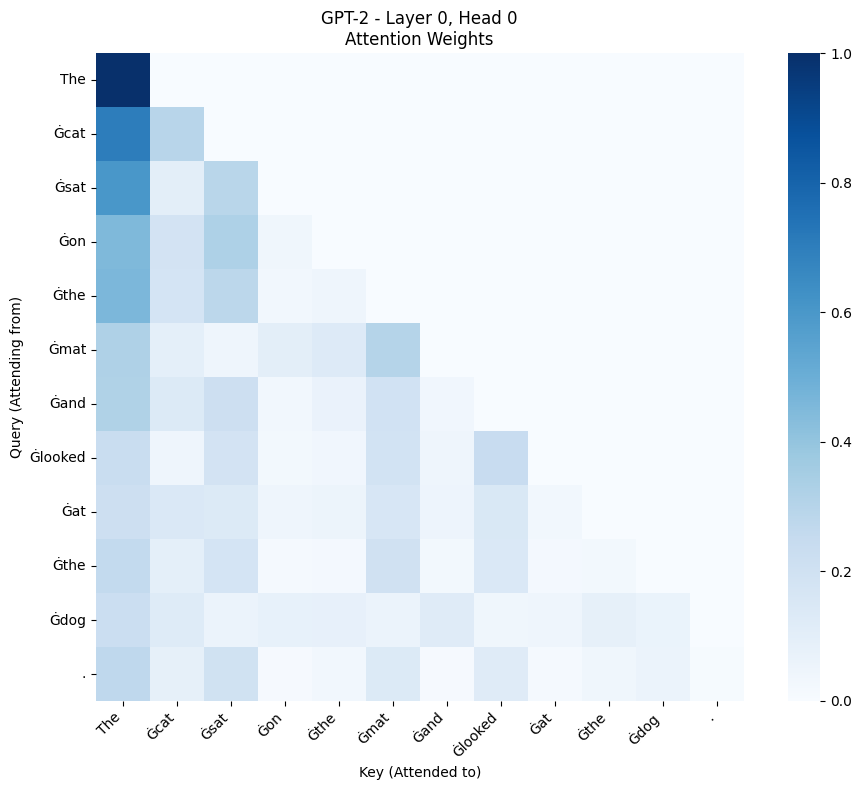

In [6]:
# Визуализируем attention для первого слоя и первой головы
plot_attention_heatmap(bert_attention, bert_tokens, 'BERT', layer_idx=0, head_idx=0)
plot_attention_heatmap(gpt2_attention, gpt2_tokens, 'GPT-2', layer_idx=0, head_idx=0)

Дополнительно: сравнение BERT и GPT-2 рядом

In [7]:
def plot_two_heatmaps(attn1, tokens1, name1, attn2, tokens2, name2, layer_idx=0, head_idx=0):
    matrix1 = attn1[layer_idx][0, head_idx].cpu().numpy()
    matrix2 = attn2[layer_idx][0, head_idx].cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(
        matrix1,
        xticklabels=tokens1,
        yticklabels=tokens1,
        cmap='Blues',
        cbar=True,
        square=True,
        ax=axes[0]
    )
    axes[0].set_title(f'{name1} - Layer {layer_idx}, Head {head_idx}')
    axes[0].set_xlabel('Key')
    axes[0].set_ylabel('Query')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)

    sns.heatmap(
        matrix2,
        xticklabels=tokens2,
        yticklabels=tokens2,
        cmap='Blues',
        cbar=True,
        square=True,
        ax=axes[1]
    )
    axes[1].set_title(f'{name2} - Layer {layer_idx}, Head {head_idx}')
    axes[1].set_xlabel('Key')
    axes[1].set_ylabel('Query')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()

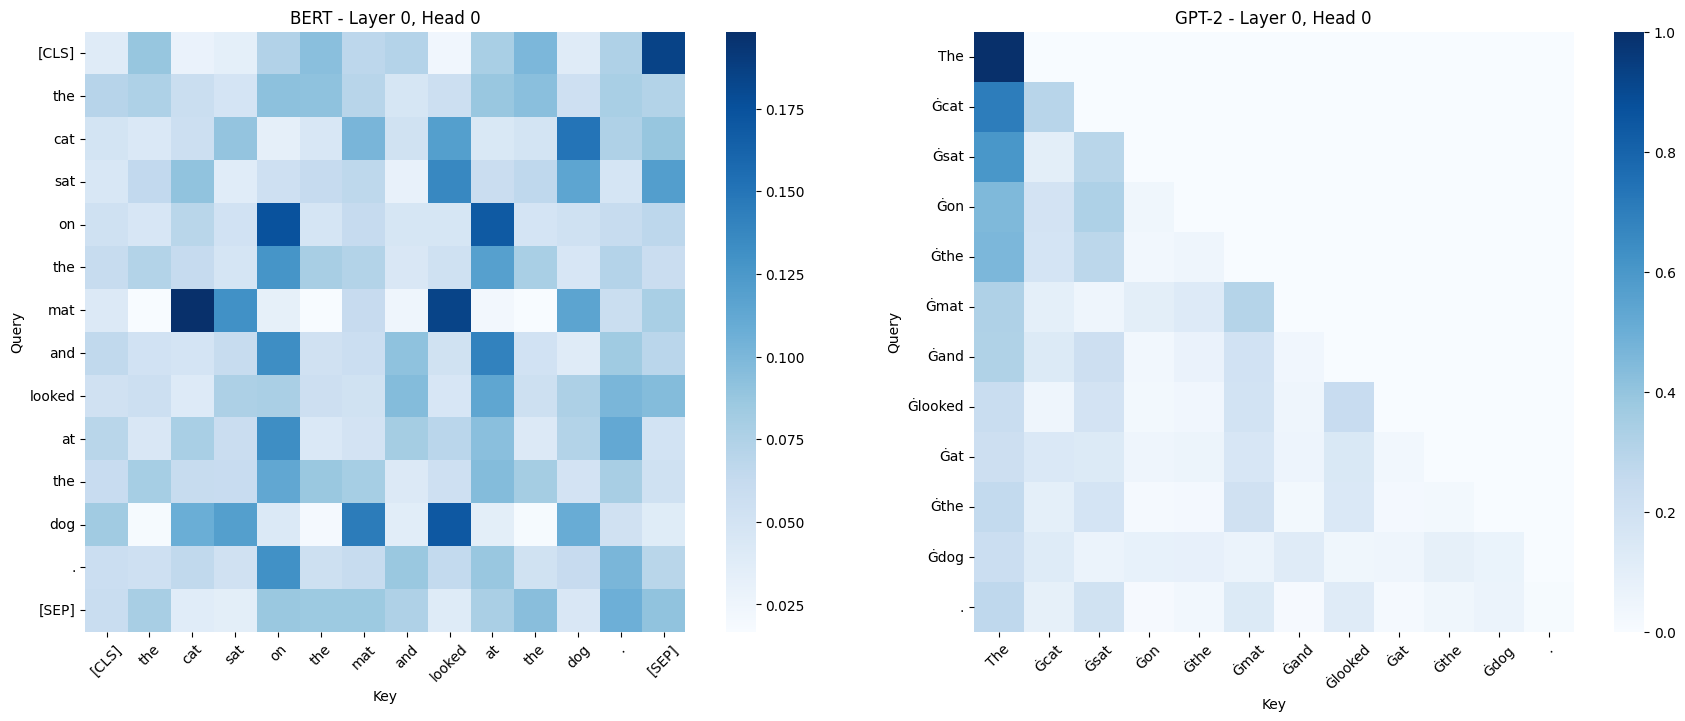

In [8]:
plot_two_heatmaps(
    bert_attention, bert_tokens, 'BERT',
    gpt2_attention, gpt2_tokens, 'GPT-2',
    layer_idx=0, head_idx=0
)

### Задание 1.4: Анализ результатов

**1. Какие различия вы заметили в attention patterns между BERT и GPT-2?**

BERT использует bidirectional attention, поэтому токен может обращать внимание и на предыдущие, и на последующие токены.  
GPT-2 использует causal attention, поэтому токен смотрит только на себя и токены слева.  
На heatmap это видно так: у BERT внимание распределено по всей матрице, а у GPT-2 заметно ограничение на будущие токены.

**2. Как изменяются attention веса в разных слоях?**
 
В нижних слоях attention чаще фокусируется на ближайших токенах и локальных связях.  
В более глубоких слоях внимание может становиться более смысловым: модель начинает связывать слова, которые логически относятся друг к другу, даже если они стоят дальше друг от друга.  
Также разные головы в разных слоях могут вести себя по-разному.

**3. Какую роль играют позиционные кодировки?**

Attention сам по себе не знает порядок слов, он видит только набор токенов.  
Позиционные кодировки добавляют информацию о позиции токена в последовательности.  
Благодаря этому модель понимает разницу между фразами с одинаковыми словами, но разным порядком.

## Часть 2 : Дополнительные задания

### Задание 2.1: Исследование Multi-Head Attention

In [9]:
def analyze_multi_head_attention(attention_weights, tokens, model_name, layer_idx=6):
    """
    Анализ того, как разные головы attention фокусируются на разных аспектах
    """
    # attention_weights[layer_idx] shape: (batch_size, num_heads, seq_len, seq_len)
    num_heads = attention_weights[layer_idx].shape[1]

    cols = 4
    rows = int(np.ceil(num_heads / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
    axes = axes.flatten()

    for head_idx in range(num_heads):
        attention_matrix = attention_weights[layer_idx][0, head_idx].cpu().numpy()

        sns.heatmap(
            attention_matrix,
            xticklabels=tokens,
            yticklabels=tokens,
            cmap='Blues',
            cbar=False,
            square=True,
            ax=axes[head_idx]
        )

        axes[head_idx].set_title(f'Head {head_idx}')
        axes[head_idx].tick_params(axis='x', rotation=45)
        axes[head_idx].tick_params(axis='y', rotation=0)

    # если лишние subplot остались пустыми
    for i in range(num_heads, len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle(f'{model_name} Multi-Head Attention - Layer {layer_idx}', fontsize=16)
    plt.tight_layout()
    plt.show()


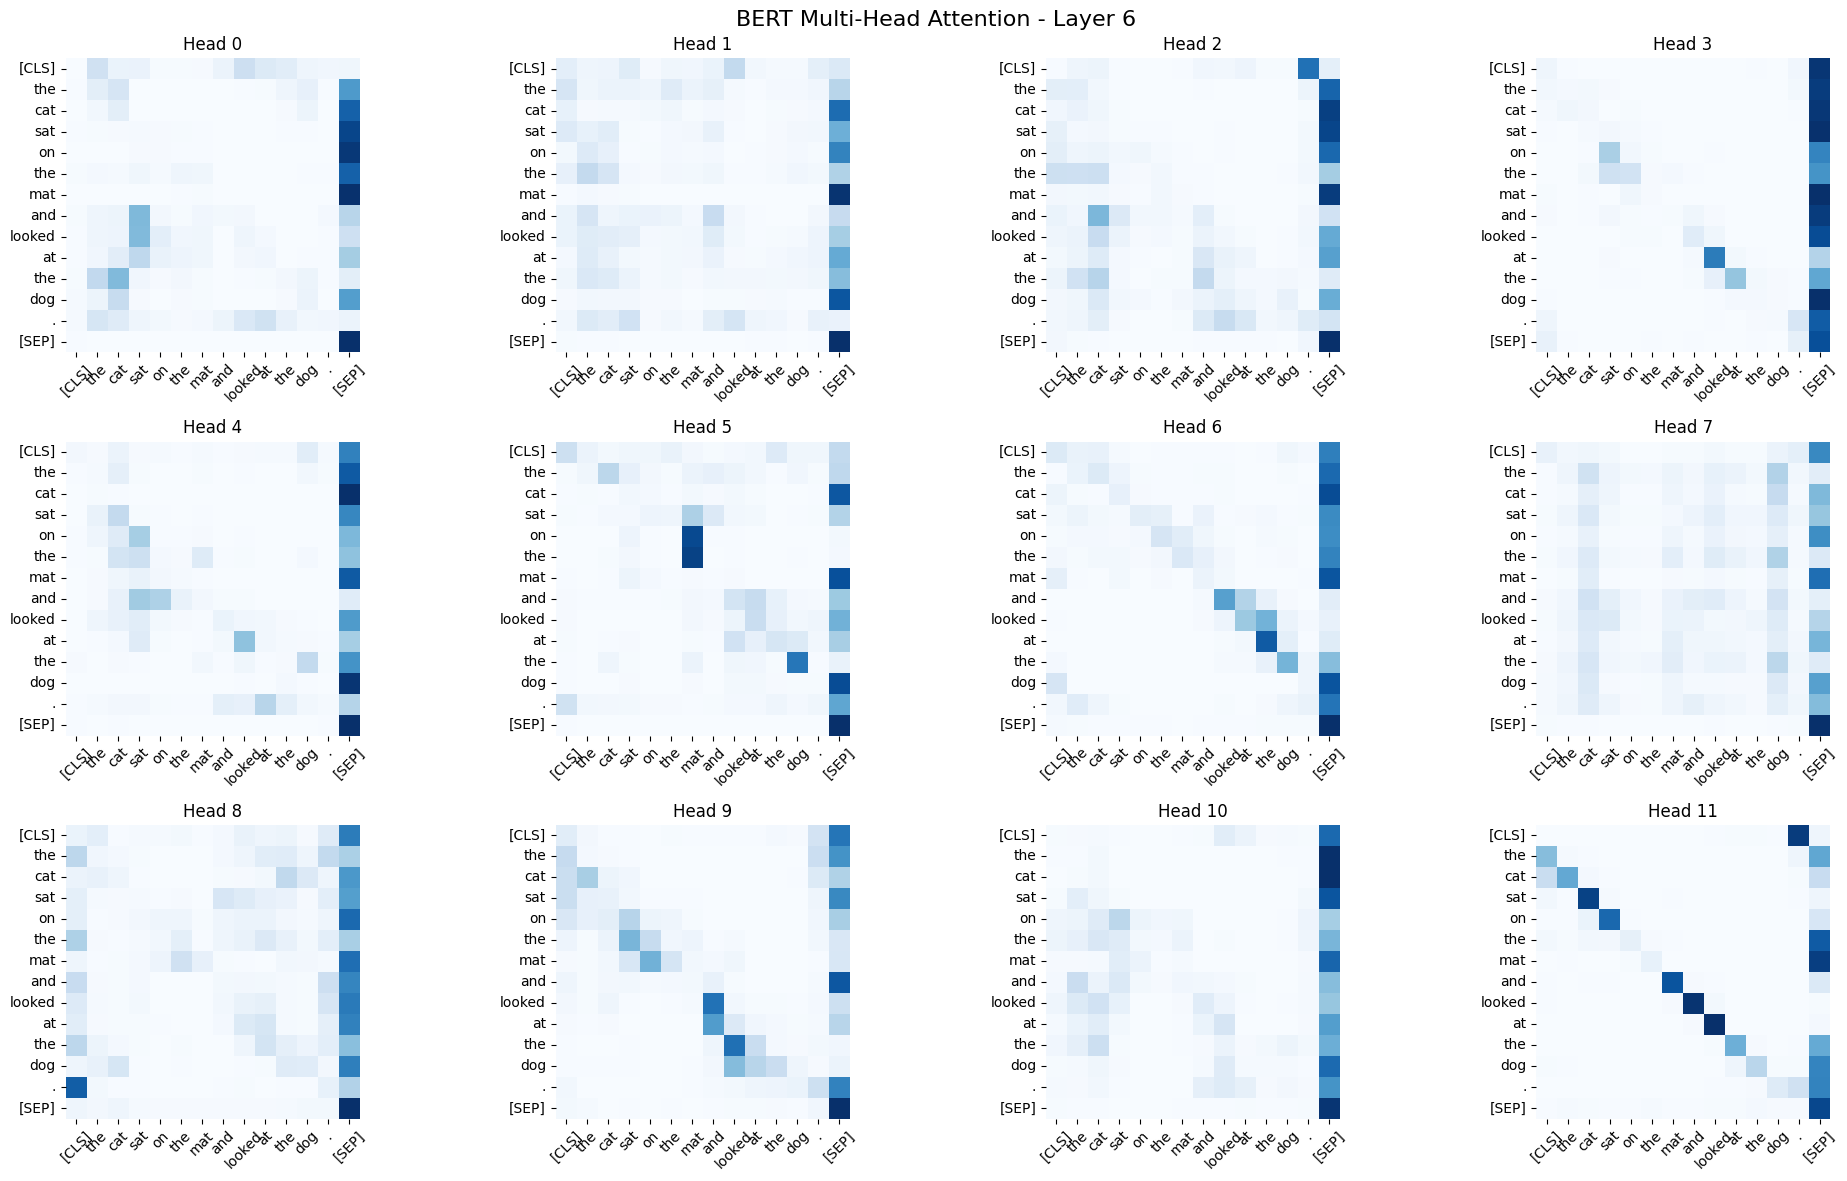

In [10]:
analyze_multi_head_attention(bert_attention, bert_tokens, 'BERT', layer_idx=6)

### Задание 2.2: Создание attention-карт для русскоязычного текста

In [11]:
from transformers import AutoTokenizer, AutoModel

# Загружаем русскоязычную модель
ru_tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")
ru_model = AutoModel.from_pretrained("DeepPavlov/rubert-base-cased", output_attentions=True)

# Русский текст для анализа
russian_text = "Кот сидел на ковре и смотрел на собаку."
print(f"Русский текст: {russian_text}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | Details
-------------------------------------------+------------+--------
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |        
cls.predictions.bias                       | UNEXPECTED |        
cls.predictions.transform.dense.weight     | UNEXPECTED |        
cls.predictions.decoder.bias               | UNEXPECTED |        
cls.seq_relationship.weight                | UNEXPECTED |        
bert.embeddings.position_ids               | UNEXPECTED |        
cls.predictions.transform.dense.bias       | UNEXPECTED |        
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |        
cls.predictions.decoder.weight             | UNEXPECTED |        
cls.seq_relationship.bias                  | UNEXPECTED |        

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Русский текст: Кот сидел на ковре и смотрел на собаку.


In [12]:
def analyze_russian_attention(text, tokenizer, model):
    """
    Анализ attention для русского текста
    """
    # Токенизация
    inputs = tokenizer(text, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    attention_weights = outputs.attentions
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    # Возьмем последний слой, первую голову
    attention_matrix = attention_weights[-1][0, 0].cpu().numpy()

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        attention_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='Blues',
        cbar=True,
        square=True,
        annot=True,
        fmt='.2f'
    )

    plt.title(f'RuBERT Attention Heatmap\nText: {text}')
    plt.xlabel('Key (Attended to)')
    plt.ylabel('Query (Attending from)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return attention_weights, tokens

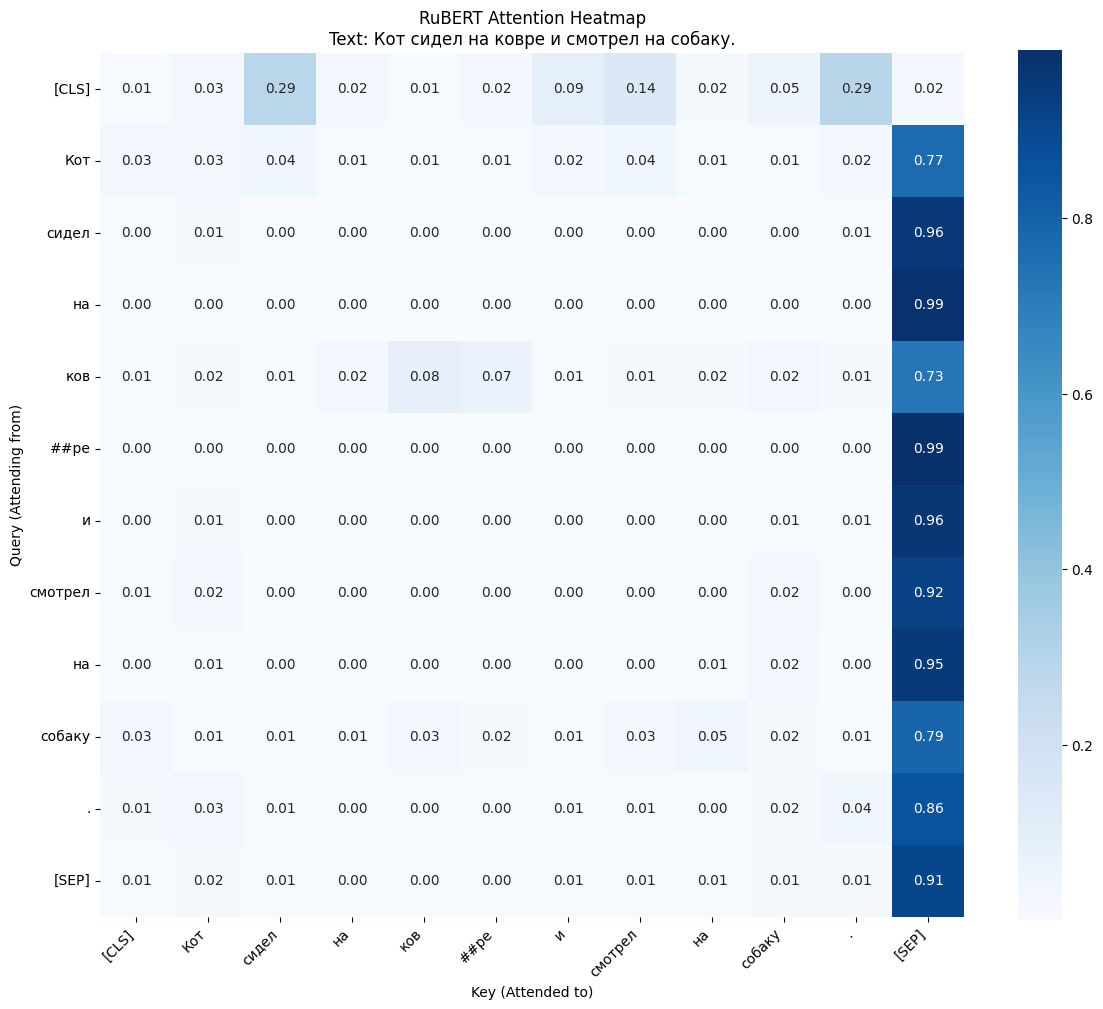


Токены: ['[CLS]', 'Кот', 'сидел', 'на', 'ков', '##ре', 'и', 'смотрел', 'на', 'собаку', '.', '[SEP]']
Количество слоев: 12
Количество голов: 12


In [13]:
# Анализируем русский текст
ru_attention, ru_tokens = analyze_russian_attention(russian_text, ru_tokenizer, ru_model)

print(f"\nТокены: {ru_tokens}")
print(f"Количество слоев: {len(ru_attention)}")
print(f"Количество голов: {ru_attention[0].shape[1]}")

In [14]:
print("English BERT tokens:", bert_tokens)
print("RuBERT tokens:", ru_tokens)

English BERT tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'and', 'looked', 'at', 'the', 'dog', '.', '[SEP]']
RuBERT tokens: ['[CLS]', 'Кот', 'сидел', 'на', 'ков', '##ре', 'и', 'смотрел', 'на', 'собаку', '.', '[SEP]']


## Итоговый анализ и выводы

### Основные различия между BERT и GPT-2

BERT использует bidirectional attention, поэтому каждый токен может учитывать и левый, и правый контекст.  
GPT-2 использует causal attention, поэтому токен может смотреть только на предыдущие токены и на самого себя.  
Из-за этого attention matrix у BERT более полная, а у GPT-2 внимание ограничено левой частью матрицы.

### Как attention головы специализируются

Разные attention головы не одинаковы по поведению.  
Некоторые головы фокусируются на ближайших словах, другие на более дальних зависимостях.  
Это показывает, что multi-head attention помогает модели одновременно учитывать несколько типов связей: локальные, синтаксические и смысловые.

### Особенности русскоязычных моделей

RuBERT работает по тому же общему принципу, что и обычный BERT, но токенизация и attention patterns зависят от особенностей русского языка.  
Русские слова имеют более богатую морфологию, поэтому модель может разбивать слова иначе и учитывать связи между падежами, формами слов и порядком слов в предложении.  
Это влияет на распределение внимания между токенами.

### Практические применения полученных знаний

Визуализация attention помогает понять, на какие части текста модель опирается при обработке входа.  
Это полезно для интерпретации поведения модели, поиска ошибок токенизации, анализа различий между архитектурами и отладки моделей под конкретные задачи.  
Также attention visualization помогает проверить, действительно ли модель использует важные слова, а не случайные или шумовые элементы.